<a href="https://colab.research.google.com/github/YuriiKlim/Amazinum_Camp/blob/Homeworks/Home_task_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home task: pandas

In [53]:
import pandas as pd
import numpy as np

# Question 1

* Load the energy data from the file Energy Indicators.xls. It is a list of
indicators of energy supply and renewable electricity production from the United Nations for the year 2013.

* It should be put into a DataFrame with the variable name of "energy"

* Make sure to exclude the footer and header information from the datafile.

* The first two columns are unneccessary, so you should get rid of them, and you should change the column labels so that the columns are:
['Country', 'Energy Supply', 'Energy Supply per Capita', '% Renewable']

In [54]:
df_energy = pd.read_excel("https://raw.githubusercontent.com/OleksiyTsebriy/Camp_2025/main/lesson_3_pandas/Energy%20Indicators.xls", header=17)

df_energy = df_energy.iloc[0:227]
df_energy = df_energy.drop(columns=["Unnamed: 0", "Unnamed: 1"])
df_energy.columns = ['Country', 'Energy Supply', 'Energy Supply per Capita', '% Renewable']

df_energy

,Country,Energy Supply,Energy Supply per Capita,% Renewable
0,Afghanistan,321,10,78.669280
1,Albania,102,35,100.000000
2,Algeria,1959,51,0.551010
3,American Samoa,...,...,0.641026
4,Andorra,9,121,88.695650
...,...,...,...,...
222,Viet Nam,2554,28,45.321520
223,Wallis and Futuna Islands,0,26,0.000000
224,Yemen,344,13,0.000000
225,Zambia,400,26,99.714670


* Convert Energy Supply to gigajoules (there are 1,000,000 gigajoules in a petajoule).

* For all countries which have missing data (e.g. data with ...) make sure this is reflected as np.NaN values.

In [55]:
# Convert columns to numeric type, incorrect values will be converted to np.nan
df_energy['Energy Supply'] = pd.to_numeric(df_energy['Energy Supply'], errors='coerce')
df_energy['Energy Supply per Capita'] = pd.to_numeric(df_energy['Energy Supply per Capita'], errors='coerce')

# Multiply the value in the “Energy Supply” column by 1,000,000
df_energy['Energy Supply'] = df_energy['Energy Supply'] * 1000000

In [56]:
df_energy

,Country,Energy Supply,Energy Supply per Capita,% Renewable
0,Afghanistan,3.210000e+08,10.0,78.669280
1,Albania,1.020000e+08,35.0,100.000000
2,Algeria,1.959000e+09,51.0,0.551010
3,American Samoa,NaN,NaN,0.641026
4,Andorra,9.000000e+06,121.0,88.695650
...,...,...,...,...
222,Viet Nam,2.554000e+09,28.0,45.321520
223,Wallis and Futuna Islands,0.000000e+00,26.0,0.000000
224,Yemen,3.440000e+08,13.0,0.000000
225,Zambia,4.000000e+08,26.0,99.714670


* Rename the following list of countries (for use in later questions):

  * Republic of Korea: South Korea,
  * United States of America: United States,
  * United Kingdom of Great Britain and Northern Ireland: United Kingdom,
  * China, Hong Kong Special Administrative Region: Hong Kong
* There are also several countries with numbers and/or parenthesis in their name. Be sure to remove these, e.g.:

  * Bolivia (Plurinational State of) should be Bolivia,
  * Switzerland17 should be Switzerland.

In [57]:
import re

In [58]:
def column_cleaner(df, column, rename_dict=None):
    """
    Clears and renames country names in the specified DataFrame column

    The function performs the following steps:
      1. If a renaming dictionary (rename_dict) is passed, applies a specific renaming.
      2. Removes any text in brackets along with the brackets.
      3. Removes digits.
      4. Remove any extra whitespaces.

    Params:
      df (pd.DataFrame): DataFrame with data.
      column (str): Name of the column to clear.
      rename_dict (dict, optional): Dictionary for renaming countries. Default None.

    Return:
      pd.DataFrame: DataFrame with cleared column.
    """
    if rename_dict:
        df[column] = df[column].replace(rename_dict)

    df[column] = df[column].apply(lambda x: re.sub(r"\s*\(.*?\)", "", x))

    df[column] = df[column].apply(lambda x: re.sub(r"\d+", "", x))

    df[column] = df[column].str.strip()

    return df

In [61]:
# Dictionary for specific country renamings
rename_dict_df_energy = {
    "Republic of Korea": "South Korea",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "China, Hong Kong Special Administrative Region": "Hong Kong"
}

df_energy = column_cleaner(df_energy, 'Country', rename_dict_df_energy)

In [62]:
# Check the cleaned country names
for country in df_energy['Country']:
  print(country, end='|')

Afghanistan|Albania|Algeria|American Samoa|Andorra|Angola|Anguilla|Antigua and Barbuda|Argentina|Armenia|Aruba|Australia|Austria|Azerbaijan|Bahamas|Bahrain|Bangladesh|Barbados|Belarus|Belgium|Belize|Benin|Bermuda|Bhutan|Bolivia|Bonaire, Sint Eustatius and Saba|Bosnia and Herzegovina|Botswana|Brazil|British Virgin Islands|Brunei Darussalam|Bulgaria|Burkina Faso|Burundi|Cabo Verde|Cambodia|Cameroon|Canada|Cayman Islands|Central African Republic|Chad|Chile|China|Hong Kong|China, Macao Special Administrative Region|Colombia|Comoros|Congo|Cook Islands|Costa Rica|Côte d'Ivoire|Croatia|Cuba|Curaçao|Cyprus|Czech Republic|Democratic People's Republic of Korea|Democratic Republic of the Congo|Denmark|Djibouti|Dominica|Dominican Republic|Ecuador|Egypt|El Salvador|Equatorial Guinea|Eritrea|Estonia|Ethiopia|Faeroe Islands|Falkland Islands|Fiji|Finland|France|French Guiana|French Polynesia|Gabon|Gambia|Georgia|Germany|Ghana|Gibraltar|Greece|Greenland|Grenada|Guadeloupe|Guam|Guatemala|Guernsey|Guinea

* Next, load the GDP data from the file "world_bank.csv". It is a csv containing countries' GDP from 1960 to 2015 from World Bank. Call this DataFrame "GDP"

In [63]:
GDP = pd.read_csv("https://raw.githubusercontent.com/YuriiKlim/Amazinum_Camp/refs/heads/Homeworks/HW_pandas/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_76261.csv")
GDP = GDP.rename(columns={'Country Name': 'Country'})

GDP

,Country,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Unnamed: 68
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.962907e+09,2.983635e+09,3.092429e+09,3.276184e+09,3.395799e+09,2.481857e+09,2.929447e+09,3.279344e+09,3.648573e+09,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.421063e+10,2.496398e+10,2.707880e+10,3.177575e+10,3.028579e+10,3.381317e+10,...,8.982778e+11,8.289428e+11,9.729989e+11,1.012306e+12,1.009721e+12,9.333918e+11,1.085745e+12,1.191423e+12,1.245472e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.723305e+10,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190495e+10,1.270788e+10,1.363076e+10,1.446909e+10,1.580376e+10,1.692109e+10,...,7.717669e+11,6.943610e+11,6.878492e+11,7.704950e+11,8.264838e+11,7.898017e+11,8.493124e+11,8.839739e+11,7.991060e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,9.049642e+10,5.276162e+10,7.369015e+10,7.945069e+10,7.089796e+10,4.850156e+10,6.650513e+10,1.043997e+11,8.482465e+10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.295848e+09,6.682677e+09,7.180765e+09,7.878760e+09,7.899738e+09,7.717145e+09,9.413404e+09,9.354903e+09,1.046822e+10,NaN
262,"Yemen, Rep.",YEM,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,4.244449e+10,3.131782e+10,2.684223e+10,2.160616e+10,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP (current US$),NY.GDP.MKTP.CD,8.748597e+09,9.225996e+09,9.813996e+09,1.085420e+10,1.195600e+10,1.306899e+10,...,3.467098e+11,3.235855e+11,3.814488e+11,4.052607e+11,3.893300e+11,3.379747e+11,4.208869e+11,4.069200e+11,3.806993e+11,NaN
264,Zambia,ZMB,GDP (current US$),NY.GDP.MKTP.CD,6.987397e+08,6.823597e+08,6.792797e+08,7.043397e+08,8.226397e+08,1.061200e+09,...,2.125122e+10,2.095841e+10,2.587360e+10,2.631151e+10,2.330867e+10,1.813776e+10,2.209642e+10,2.916378e+10,2.757796e+10,NaN


* Make sure to skip the header, and rename the following list of countries:

  * Korea, Rep.: South Korea,
  * Iran, Islamic Rep.: Iran,
  * Hong Kong SAR, China: Hong Kong

In [64]:
rename_dict_GDP = {
    "Korea, Rep.": "South Korea",
    "Iran, Islamic Rep.": "Iran",
    "Hong Kong SAR, China": "Hong Kong"
}

GDP = column_cleaner(GDP, 'Country', rename_dict_GDP)

In [65]:
for country in GDP['Country']:
  print(country, end='|')

Aruba|Africa Eastern and Southern|Afghanistan|Africa Western and Central|Angola|Albania|Andorra|Arab World|United Arab Emirates|Argentina|Armenia|American Samoa|Antigua and Barbuda|Australia|Austria|Azerbaijan|Burundi|Belgium|Benin|Burkina Faso|Bangladesh|Bulgaria|Bahrain|Bahamas, The|Bosnia and Herzegovina|Belarus|Belize|Bermuda|Bolivia|Brazil|Barbados|Brunei Darussalam|Bhutan|Botswana|Central African Republic|Canada|Central Europe and the Baltics|Switzerland|Channel Islands|Chile|China|Cote d'Ivoire|Cameroon|Congo, Dem. Rep.|Congo, Rep.|Colombia|Comoros|Cabo Verde|Costa Rica|Caribbean small states|Cuba|Curacao|Cayman Islands|Cyprus|Czechia|Germany|Djibouti|Dominica|Denmark|Dominican Republic|Algeria|East Asia & Pacific|Early-demographic dividend|East Asia & Pacific|Europe & Central Asia|Europe & Central Asia|Ecuador|Egypt, Arab Rep.|Euro area|Eritrea|Spain|Estonia|Ethiopia|European Union|Fragile and conflict affected situations|Finland|Fiji|France|Faroe Islands|Micronesia, Fed. Sts.|

* Finally, load the "Sciamgo Journal and Country Rank data for Energy Engineering and Power Technology". It ranks countries based on their journal contributions in the aforementioned area. Call this DataFrame "ScimEn"

In [66]:
ScimEn = pd.read_excel("https://raw.githubusercontent.com/YuriiKlim/Amazinum_Camp/refs/heads/Homeworks/HW_pandas/scimagojr%20country%20rank%201996-2023.xlsx", nrows=15)

ScimEn

,Rank,Country,Region,Documents,Citable documents,Citations,Self-citations,Citations per document,H index
0,1,China,Asiatic Region,402188,400158,5077232,3511673,12.62,343
1,2,United States,Northern America,208042,203356,3540288,1004877,17.02,458
2,3,India,Asiatic Region,81853,79757,968523,369256,11.83,237
3,4,Japan,Asiatic Region,58342,57735,717946,154848,12.31,228
4,5,United Kingdom,Western Europe,56288,54713,1095371,179764,19.46,293
5,6,Germany,Western Europe,50906,49773,777362,160302,15.27,252
6,7,Russian Federation,Eastern Europe,46186,45868,217996,96688,4.72,112
7,8,Canada,Northern America,41209,40390,915491,142691,22.22,284
8,9,Italy,Western Europe,38700,36909,639473,147302,16.52,209
9,10,South Korea,Asiatic Region,38362,38046,618762,105419,16.13,198


* Join the three datasets: Energy, GDP, and ScimEn into a new dataset (using the intersection of country names). Use only the 10 years (2006-2015) of GDP data and only the top 15 countries by Scimagojr 'Rank' (Rank 1 through 15).

In [67]:
def answer_one(dataframes, join_column, keep_columns=None, drop_columns=None, index_column=None):
    """
    Joins a list of two or more DataFrames by the specified column (join_column)
    using inner join. Optionally, you can leave only certain columns,
    remove unnecessary ones and set one of the columns as the index of the final DataFrame.

    Params:
      dataframes (list): A list of DataFrames to join (must contain at least two DataFrames).
      join_column (str): The name of the column to be joined.
      keep_columns (list, optional): A list of columns to keep in the final DataFrame.
      drop_columns (list, optional): A list of columns to drop from the final DataFrame.
      index_column (str, optional): The name of the column that will become the index of the final DataFrame.

    Return:
      pd.DataFrame: Combined DataFrame filtered according to additional parameters.
    """
    if len(dataframes) < 2:
        raise ValueError("You need to pass at least two DataFrames for merging.")

    # start with the first DataFrame
    merged_df = dataframes[0]

    # Consistently combine all DataFrames by the specified column
    for df in dataframes[1:]:
        merged_df = pd.merge(merged_df, df, on=join_column, how='inner')

    # If a column is specified for indexing, set it as an index
    if index_column:
        merged_df = merged_df.set_index(index_column)

    # If a list of columns is specified to be saved, only those columns are saved
    if keep_columns:
        merged_df = merged_df[keep_columns]

    # If a list of columns to delete is specified, delete them
    if drop_columns:
        merged_df = merged_df.drop(columns=drop_columns)

    return merged_df

* The index of this DataFrame should be the name of the country, and the columns should be
['Rank', 'Documents', 'Citable documents', 'Citations', 'Self-citations', 'Citations per document', 'H index', 'Energy Supply', 'Energy Supply per Capita', '% Renewable', '2006', '2007', '2008', '2009', '2010', '2011', 2012', '2013', '2014', '2015']

Function "answer_one" should return the resulted DataFrame (20 columns and 15 entries)

In [68]:
keep_columns=['Rank', 'Documents', 'Citable documents', 'Citations',
              'Self-citations', 'Citations per document', 'H index',
              'Energy Supply', 'Energy Supply per Capita', '% Renewable',
              '2006', '2007', '2008', '2009', '2010', '2011', '2012',
              '2013', '2014', '2015']

answer_one = answer_one([ScimEn, GDP, df_energy], 'Country',
                             keep_columns=keep_columns,
                             index_column='Country')

In [69]:
answer_one

,Rank,Documents,Citable documents,Citations,Self-citations,Citations per document,H index,Energy Supply,Energy Supply per Capita,% Renewable,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
Country,,,,,,,,,,,,,,,,,,,,
China,1,402188,400158,5077232,3511673,12.62,343,1.271910e+11,93.0,19.754910,2.752119e+12,3.550328e+12,4.594337e+12,5.101691e+12,6.087192e+12,7.551546e+12,8.532185e+12,9.570471e+12,1.047562e+13,1.106157e+13
United States,2,208042,203356,3540288,1004877,17.02,458,9.083800e+10,286.0,11.570980,1.381558e+13,1.447423e+13,1.476986e+13,1.447807e+13,1.504897e+13,1.559973e+13,1.625397e+13,1.688068e+13,1.760814e+13,1.829502e+13
India,3,81853,79757,968523,369256,11.83,237,3.319500e+10,26.0,14.969080,9.402599e+11,1.216736e+12,1.198895e+12,1.341888e+12,1.675616e+12,1.823052e+12,1.827638e+12,1.856722e+12,2.039126e+12,2.103588e+12
Japan,4,58342,57735,717946,154848,12.31,228,1.898400e+10,149.0,10.232820,4.601663e+12,4.579751e+12,5.106679e+12,5.289493e+12,5.759072e+12,6.233147e+12,6.272363e+12,5.212328e+12,4.896994e+12,4.444931e+12
United Kingdom,5,56288,54713,1095371,179764,19.46,293,7.920000e+09,124.0,10.600470,2.708442e+12,3.090510e+12,2.929412e+12,2.412840e+12,2.485483e+12,2.663806e+12,2.707090e+12,2.784854e+12,3.064708e+12,2.927911e+12
Germany,6,50906,49773,777362,160302,15.27,252,1.326100e+10,165.0,17.901530,3.046309e+12,3.484057e+12,3.808786e+12,3.479801e+12,3.468154e+12,3.824829e+12,3.597897e+12,3.808086e+12,3.965801e+12,3.423568e+12
Russian Federation,7,46186,45868,217996,96688,4.72,112,3.070900e+10,214.0,17.288680,9.899321e+11,1.299703e+12,1.660848e+12,1.222646e+12,1.524917e+12,2.045923e+12,2.208294e+12,2.292470e+12,2.059242e+12,1.363482e+12
Canada,8,41209,40390,915491,142691,22.22,284,1.043100e+10,296.0,61.945430,1.319265e+12,1.468820e+12,1.552990e+12,1.374625e+12,1.617343e+12,1.793327e+12,1.828366e+12,1.846597e+12,1.805750e+12,1.556509e+12
Italy,9,38700,36909,639473,147302,16.52,209,6.530000e+09,109.0,33.667230,1.958564e+12,2.222524e+12,2.417508e+12,2.209484e+12,2.144936e+12,2.306974e+12,2.097929e+12,2.153226e+12,2.173256e+12,1.845428e+12


# Answer the following questions in the context of only the top 15 countries by Scimagojr Rank (aka the DataFrame returned by answer_one())

# Question 2

What is the average GDP over the last 10 years for each country? (exclude missing values from this calculation.)

This function should return a Series named avgGDP with 15 countries and their average GDP sorted in descending order.

In [70]:
from pandas.api.types import is_numeric_dtype

def answer_two(df, columns, row_names_col=None):
    """
    Calculates the average for the specified columns for each row.
      - Checks if each column is present in the DataFrame.
      - Checks that all specified columns contain numeric data.
      - Calculates the average of the specified columns for each row.
      - If row_names_col is specified, uses the value of this column as the index of the result.
      - Returns a pandas.Series named 'avgGDP', sorted in descending order.

    params:
      df (pd.DataFrame): The input DataFrame.
      columns (list): The list of column names for which the average is calculated.
      row_names_col (str, optional): The name of the column containing the row names.
                                     If not specified, the starting index of the DataFrame is used.

    Return:
      pd.Series: A series with average values sorted in descending order.
    """
    # Checking the presence and number of columns
    for col in columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' is not in the DataFrame.")
        if not is_numeric_dtype(df[col]):
            raise ValueError(f"Column '{col}' does not contain numerical data.")

    # Calculate the average for the specified columns for each row
    avg_series = df[columns].mean(axis=1, skipna=True)

    # If a column for row names is specified, check for its presence and use it as an index
    if row_names_col:
        if row_names_col not in df.columns:
            raise ValueError(f"Column with row names '{row_names_col}' is not in the DataFrame.")
        avg_series.index = df[row_names_col]

    # Set the name of the Series
    avg_series.name = "avgGDP"

    # Sort
    avg_series = avg_series.sort_values(ascending=False)
    #avg_series = avg_series.apply(lambda x: f"{x:,.0f}".replace(",", "."))

    return avg_series

In [71]:
avgGDP = answer_two(answer_one, ['2006', '2007', '2008', '2009', '2010',
                                '2011', '2012', '2013', '2014', '2015'])

avgGDP

Country
United States         1.572243e+13
China                 6.927707e+12
Japan                 5.239642e+12
Germany               3.590729e+12
United Kingdom        2.777505e+12
France                2.692000e+12
Italy                 2.152983e+12
Brazil                1.988889e+12
Russian Federation    1.666746e+12
Canada                1.616359e+12
India                 1.602352e+12
Spain                 1.406644e+12
South Korea           1.221328e+12
Australia             1.207997e+12
Iran                  4.567516e+11
Name: avgGDP, dtype: float64

# Question 3

By how much had the GDP changed over the 10 year span for the country with the 6th largest average GDP?

This function should return a single number.

Added the creation of graphics on my own

In [72]:
import matplotlib.pyplot as plt


def answer_three_plus(df, index_value, columns_list):
    """
    Calculates the percentage change in value from the first to the last column for a given index
    and draws a graph with vertices on the values of each column with captions by column name.
      The function performs:
      - Checks if the specified index is present in the DataFrame.
      - Checks if all columns from the list are present in the DataFrame.
      - Checks if all values in the specified columns are numeric.
      - Calculate the percentage change using the formula:
            ((last value - first value) / first value) * 100
      - Drawing a graph where the x-axis shows the names of the columns,
        and their values on the y-axis, with vertices (markers) and labels.
      - Throws an error if the first value is 0.

    Params:
      df (pd.DataFrame): The input DataFrame.
      index_value: The index (row) value for which to calculate.
      columns_list (list): A list of column names for which the percentage change will be calculated.
                           The first element is the starting value, the last is the ending value.

    Return:
      float: Percentage change from the first to the last column.
    """
    # Checking for the presence of a given index in a DataFrame
    if index_value not in df.index:
        raise ValueError(f"Index '{index_value}' not found in DataFrame.")

    # Checking the availability of each column
    for col in columns_list:
        if col not in df.columns:
            raise ValueError(f"The '{col}' column is not in the DataFrame.")

    # Get values from specified columns for a given index
    row_values = df.loc[index_value, columns_list]

    # Checking if all data is numeric
    if not is_numeric_dtype(row_values):
        raise ValueError("One or more of the values in these columns are not numeric.")

    first_value = row_values.iloc[0]
    last_value = row_values.iloc[-1]

    # Check to avoid division by zero
    if first_value == 0:
        raise ValueError("If the first value is zero, it is impossible to calculate the percentage change.")

    # Calculating the percentage change
    percentage_change = ((last_value - first_value) / first_value) * 100

    # Building a graph
    x = range(len(columns_list))
    plt.figure(figsize=(10, 6))
    plt.plot(x, row_values, marker='o', linestyle='-')
    plt.xticks(x, columns_list)
    plt.title(f"The value for {index_value} (Percentage change: {percentage_change:.2f}%)")
    plt.xlabel("Years")
    plt.ylabel("GDP")
    plt.grid(True)
    plt.show()

    return percentage_change

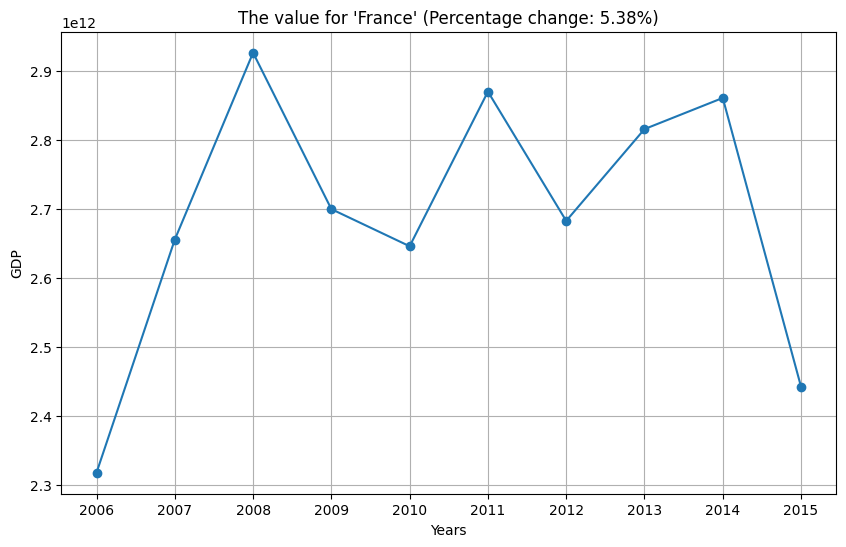

5.376589824234024

In [73]:
change = answer_three_plus(answer_one, 'France', ['2006', '2007', '2008', '2009', '2010',
                                          '2011', '2012', '2013', '2014', '2015'])
change

# Question 4

Create a new column that is the ratio of Self-Citations to Total Citations. What is the maximum value for this new column, and what country has the highest ratio?

This function should return a tuple with the name of the country and the ratio.

In [74]:
# Create a new column “Self-Citations Ratio” as the ratio of “Self-citations” to “Citations”
answer_one["Self-Citations Ratio"] = answer_one["Self-citations"] / answer_one["Citations"]

answer_one[["Self-citations", "Citations", "Self-Citations Ratio"]]

,Self-citations,Citations,Self-Citations Ratio
Country,,,
China,3511673,5077232,0.691651
United States,1004877,3540288,0.283840
India,369256,968523,0.381257
Japan,154848,717946,0.215682
United Kingdom,179764,1095371,0.164112
Germany,160302,777362,0.206213
Russian Federation,96688,217996,0.443531
Canada,142691,915491,0.155863
Italy,147302,639473,0.230349


In [75]:
def answer_four(df, column):
    """
    Accepts a DataFrame and a column name.
    Finds the largest value in the specified column and returns a tuple (index, value)
    for the row with the maximum value.

    Params:
      df (pd.DataFrame): Input DataFrame.
      column (str): The name of the column in which we are looking for the largest value.

    REturn:
      tuple: A tuple (index, value) of the row with the highest value in the specified column.
    """
    # Checking the presence of a column in a DataFrame
    if column not in df.columns:
        raise ValueError(f"The '{column}' column is not in the DataFrame.")

    # Find the index of the row with the maximum value in the column
    max_index = df[column].idxmax()
    max_value = df.loc[max_index, column]

    return (max_index, max_value)

In [76]:
result = answer_four(answer_one, "Self-Citations Ratio")
result

('China', 0.6916510807463594)

# Question 5

Create a column that estimates the population using Energy Supply and Energy Supply per capita. What is the third most populous country according to this estimate?

This function should return a single string value.

In [77]:
# Calculate the Population column as the ratio of Energy Supply to Energy Supply per Capita
answer_one["Population"] = answer_one["Energy Supply"] / answer_one["Energy Supply per Capita"]

In [78]:
answer_one[["Energy Supply", "Energy Supply per Capita", "Population"]]

,Energy Supply,Energy Supply per Capita,Population
Country,,,
China,1.271910e+11,93.0,1.367645e+09
United States,9.083800e+10,286.0,3.176154e+08
India,3.319500e+10,26.0,1.276731e+09
Japan,1.898400e+10,149.0,1.274094e+08
United Kingdom,7.920000e+09,124.0,6.387097e+07
Germany,1.326100e+10,165.0,8.036970e+07
Russian Federation,3.070900e+10,214.0,1.435000e+08
Canada,1.043100e+10,296.0,3.523986e+07
Italy,6.530000e+09,109.0,5.990826e+07


In [79]:
def answer_five(df, column, rank):
    """
    Accepts a DataFrame, a column name, and a number that identifies the position in the sorted list.
    The function sorts the values in the specified column in descending order and returns the index of the item,
    that occupies the specified position.

    Params:
        df (pd.DataFrame): The input DataFrame.
        column (str): The name of the column to be sorted by.
        rank (int): The rank number.
                    If positive - 1 means the largest value, 2 - the second, 3 - the third, etc.
                    If negative, (-1) means the last value, (-2) means the penultimate value, etc.

    Return:
        Index of the element (line) with the specified position in the "top".

    ValueError:
        If the specified column is missing or the rank is out of bounds.
    """
    if column not in df.columns:
        raise ValueError(f"The '{column}' column is not in the DataFrame.")

    # Sort the values in the column in descending order (largest value first)
    sorted_series = df[column].sort_values(ascending=False)
    n = len(sorted_series)

    # If the rank is positive (for example, 1, 2, 3, ...)
    if rank > 0:
        if rank > n:
            raise ValueError(f"The requested rank {rank} exceeds the number of elements ({n}).")
        result_index = sorted_series.index[rank - 1]
    # If the rank is negative (for example, -1, -2, ...)
    elif rank < 0:
        if abs(rank) > n:
            raise ValueError(f"The requested rank {rank} exceeds the number of elements ({n}).")
        result_index = sorted_series.index[rank]
    else:
        raise ValueError("The rank cannot be zero.")

    return result_index

In [91]:
result = answer_five(answer_one, 'Population', 3)
print(result)

United States


# Question 6

Create a column that estimates the number of citable documents per person. What is the correlation between the number of citable documents per capita and the energy supply per capita? Use the .corr() method, (Pearson's correlation).

This function should return a single number.

In [92]:
answer_one["Citable documents per person"] = answer_one["Citable documents"] / answer_one["Population"]

answer_one[["Citable documents", "Population", "Citable documents per person"]]

,Citable documents,Population,Citable documents per Population
Country,,,
China,400158,1.367645e+09,0.000293
United States,203356,3.176154e+08,0.000640
India,79757,1.276731e+09,0.000062
Japan,57735,1.274094e+08,0.000453
United Kingdom,54713,6.387097e+07,0.000857
Germany,49773,8.036970e+07,0.000619
Russian Federation,45868,1.435000e+08,0.000320
Canada,40390,3.523986e+07,0.001146
Italy,36909,5.990826e+07,0.000616


In [93]:
def answer_six(df, col1, col2):
    """
    Calculates the Pearson's correlation coefficient between two given DataFrame columns.

    Params:
      df (pd.DataFrame): The input DataFrame.
      col1 (str): The name of the first column.
      col2 (str): The name of the second column.

    Return:
      float: Pearson correlation between col1 and col2.

    ValueError:
      If one of the columns is missing from the DataFrame.
    """
    # Checking for columns in a DataFrame
    if col1 not in df.columns:
        raise ValueError(f"Column '{col1}' is not in the DataFrame.")
    if col2 not in df.columns:
        raise ValueError(f"Column '{col2}' is not in the DataFrame.")

    # Calculate Pearson's correlation between two columns
    correlation = df[col1].corr(df[col2], method='pearson')

    return correlation

In [94]:
correlation_value = answer_six(answer_one, 'Citable documents per person', 'Energy Supply per Capita')
correlation_value

0.7019601723071187

# Question 7

Use the following dictionary to group the Countries by Continent, then create a dateframe that displays the sample size (the number of countries in each continent bin), and the sum, mean, and std deviation for the estimated population of each country.

This function should return a DataFrame with index named Continent ['Asia', 'Australia', 'Europe', 'North America', 'South America'] and columns ['size', 'sum', 'mean', 'std']

In [96]:
ContinentDict  = {
    'China':'Asia',
    'United States':'North America',
    'Japan':'Asia',
    'United Kingdom':'Europe',
    'Russian Federation':'Europe',
    'Canada':'North America',
    'Germany':'Europe',
    'India':'Asia',
    'France':'Europe',
    'South Korea':'Asia',
    'Italy':'Europe',
    'Spain':'Europe',
    'Iran':'Asia',
    'Australia':'Australia',
    'Brazil':'South America'
}

answer_one['Continent'] = answer_one.index.map(ContinentDict)

In [98]:
answer_one['Continent']

Country
China                          Asia
United States         North America
India                          Asia
Japan                          Asia
United Kingdom               Europe
Germany                      Europe
Russian Federation           Europe
Canada                North America
Italy                        Europe
South Korea                    Asia
Iran                           Asia
France                       Europe
Spain                        Europe
Australia                 Australia
Brazil                South America
Name: Continent, dtype: object

In [102]:
def answer_seven(df):
    """
    Creates a dataframe that displays the sample size (number of countries in each continental group),
    and the sum, mean, and standard deviation of the estimated population.

    Return:
      pd.DataFrame: A data frame with the Continent index ['Asia', 'Australia', 'Europe', 'North America', 'South America']
                    and columns ['size', 'sum', 'mean', 'std'].
    """
    # Grouping by continent and aggregating values in the 'Population' column'
    summary = df.groupby("Continent")["Population"].agg(
        size="count",
        sum="sum",
        mean="mean",
        std="std"
    )

    # Setting the index order according to the requirements
    desired_index = ['Asia', 'Australia', 'Europe', 'North America', 'South America']
    summary = summary.reindex(desired_index)

    return summary

In [103]:
summary_df = answer_seven(answer_one, 'Continent', 'Population')
summary_df

,size,sum,mean,std
Continent,,,,
Asia,5,2.898666e+09,5.797333e+08,6.790979e+08
Australia,1,2.331602e+07,2.331602e+07,NaN
Europe,6,4.579297e+08,7.632161e+07,3.464767e+07
North America,2,3.528552e+08,1.764276e+08,1.996696e+08
South America,1,2.059153e+08,2.059153e+08,NaN
